In [2]:
import pandas as pd
import numpy as np
import talib
import matplotlib.pyplot as plt
import altair as alt
import seaborn as sns
import yfinance as yf
import bt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from hyperopt import tpe, hp, fmin, STATUS_OK
from hyperopt.pyll import scope

c:\Users\ASUS\anaconda3\envs\stock_trading\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Load Data

In [3]:
# Load BCA data
tickers = ["BBCA.JK"]
bbca = yf.Ticker("BBCA.JK")
data = bbca.history(start="2015-01-01")
data = data.reset_index()

In [4]:
data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits'],
      dtype='object')

# Data Visualization

In [7]:
# Plot daily Close
alt.Chart(data).mark_line().encode(
    x=alt.X('Date:T', title='Date'),
    y=alt.Y('Close:Q', title='Close Price')
).properties(
    width=800,
    height=400
).interactive()

alt.Chart(...)

In [6]:
open_close_color = (
    alt.when("datum.Open <= datum.Close")
    .then(alt.value("#06982d"))
    .otherwise(alt.value("#ae1325"))
)
base = alt.Chart(data).encode(
    alt.X('Date:T')
        .axis(format='%Y-%m-%d', labelAngle=-45)
        .title('BBCA Stock in Candlestick'),
    color=open_close_color
)

rule = base.mark_rule().encode(
    alt.Y('Low:Q')
        .title('Price')
        .scale(zero=False),
    alt.Y2('High:Q')
)

bar = base.mark_bar().encode(
    alt.Y('Open:Q'),
    alt.Y2('Close:Q')
)

(rule + bar).properties(
    width=800,
    height=400
).interactive()

alt.LayerChart(...)

It seems we have downward trend on the beginning of January

/tmp/ipython-input-1722493338.py:3: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



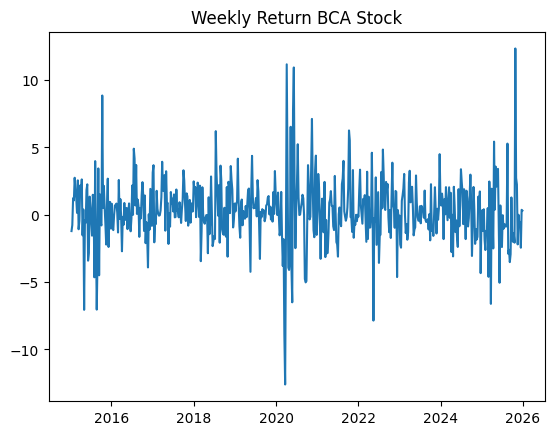

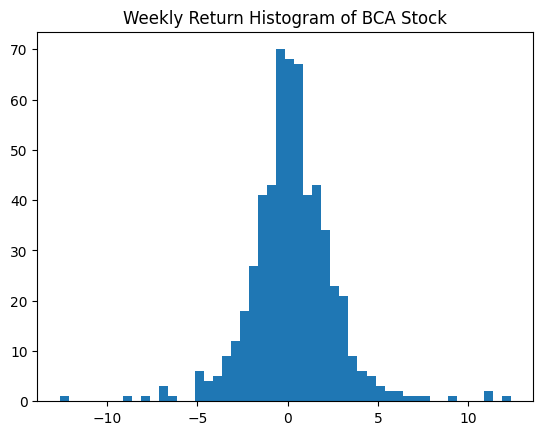

In [ ]:
# Check the weekly return
df_weekly = data.resample("W").mean()
df_weekly["weekly_return"] = df_weekly["Close"].pct_change() * 100

plt.plot(df_weekly["weekly_return"])
plt.title("Weekly Return BCA Stock")
plt.show()

# Plot the histogram
plt.hist(df_weekly["weekly_return"], bins=50)
plt.title("Weekly Return Histogram of BCA Stock")
plt.show()

BBCA’s returns are generally stable, but exhibit volatility spikes during major market events. The weekly return distribution is centered around zero with most returns within ±5%, showing occasional large deviations.

# Data Preprocessing

## Split to Train and Test

In [ ]:
train_df = data[(data.index.year >= 2021) & (data.index.year < 2025)]
test_df = data[data.index.year >= 2025]

In [ ]:
train_df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-01-04 00:00:00+07:00,5997.505001,6046.014232,5926.946118,6028.374512,47937000,0.0,0.0
2021-01-05 00:00:00+07:00,6050.424453,6253.281250,6041.604593,6253.281250,104831000,0.0,0.0
2021-01-06 00:00:00+07:00,6218.001601,6240.051252,6068.063974,6125.393066,89753500,0.0,0.0
2021-01-07 00:00:00+07:00,6173.902226,6218.001528,6094.523483,6143.032715,71360000,0.0,0.0
2021-01-08 00:00:00+07:00,6204.772162,6244.461536,6151.852996,6218.001953,75033500,0.0,0.0


# Trading Strategy

## Create Trading Eval Function

### Permute Time Series
This function creates a randomized (permuted) version of an OHLC price series while preserving realistic market structure such as gaps and intrabar ranges.
It is a classic price-permutation / bootstrap technique often used in strategy validation and backtesting (e.g. similar to ideas in Marcos López de Prado).



In [ ]:
def get_permutation(
    df: pd.DataFrame,
    start_index: int = 0,
    seed: int | None = None
) -> pd.DataFrame:
    """
    Generate a permuted OHLC price series by shuffling log-return components
    while preserving realistic market structure (gaps + intrabar dynamics).

    Parameters
    ----------
    df : pd.DataFrame
        Original OHLC data with columns ['Open', 'High', 'Low', 'Close']
    start_index : int, default 0
        Index where permutation begins. Data before this index is kept intact.
    seed : int or None
        Random seed for reproducibility

    Returns
    -------
    pd.DataFrame
        Permuted OHLC DataFrame with the same index as the input
    """

    assert start_index >= 0, "start_index must be non-negative"
    np.random.seed(seed)

    # ------------------------------------------------------------------
    # Basic setup
    # ------------------------------------------------------------------
    time_index = df.index
    n_bars = len(df)

    # First bar that will be permuted
    perm_start = start_index + 1
    n_perm_bars = n_bars - perm_start

    # ------------------------------------------------------------------
    # Convert OHLC prices to log-space
    # ------------------------------------------------------------------
    log_ohlc = np.log(df[['Open', 'High', 'Low', 'Close']])

    # ------------------------------------------------------------------
    # Store the anchor bar (starting point for reconstruction)
    # ------------------------------------------------------------------
    start_bar_log = log_ohlc.iloc[start_index].to_numpy()

    # ------------------------------------------------------------------
    # Decompose price movements into log-return components
    # ------------------------------------------------------------------

    # Gap return: Open_t relative to Close_{t-1}
    rel_open = (log_ohlc['Open'] - log_ohlc['Close'].shift()).to_numpy()

    # Intrabar movements relative to Open_t
    rel_high = (log_ohlc['High'] - log_ohlc['Open']).to_numpy()
    rel_low = (log_ohlc['Low'] - log_ohlc['Open']).to_numpy()
    rel_close = (log_ohlc['Close'] - log_ohlc['Open']).to_numpy()

    # Keep only the portion that will be permuted
    rel_open = rel_open[perm_start:]
    rel_high = rel_high[perm_start:]
    rel_low = rel_low[perm_start:]
    rel_close = rel_close[perm_start:]

    # ------------------------------------------------------------------
    # Permute components independently
    # ------------------------------------------------------------------

    idx = np.arange(n_perm_bars)

    # Shuffle intrabar dynamics together (shape of candles)
    perm_intrabar = np.random.permutation(idx)
    rel_high = rel_high[perm_intrabar]
    rel_low = rel_low[perm_intrabar]
    rel_close = rel_close[perm_intrabar]

    # Shuffle gap returns independently
    perm_gap = np.random.permutation(idx)
    rel_open = rel_open[perm_gap]

    # ------------------------------------------------------------------
    # Reconstruct the permuted OHLC series (still in log-space)
    # ------------------------------------------------------------------
    perm_log_ohlc = np.zeros((n_bars, 4))

    # Copy real data before permutation start
    perm_log_ohlc[:start_index] = log_ohlc.iloc[:start_index].to_numpy()

    # Set anchor bar
    perm_log_ohlc[start_index] = start_bar_log

    # Sequentially rebuild prices
    for i in range(perm_start, n_bars):
        k = i - perm_start

        # Open_t = Close_{t-1} + gap
        perm_log_ohlc[i, 0] = perm_log_ohlc[i - 1, 3] + rel_open[k]

        # Intrabar prices relative to Open_t
        perm_log_ohlc[i, 1] = perm_log_ohlc[i, 0] + rel_high[k]   # High
        perm_log_ohlc[i, 2] = perm_log_ohlc[i, 0] + rel_low[k]    # Low
        perm_log_ohlc[i, 3] = perm_log_ohlc[i, 0] + rel_close[k]  # Close

    # ------------------------------------------------------------------
    # Convert back to price space
    # ------------------------------------------------------------------
    perm_ohlc = np.exp(perm_log_ohlc)

    return pd.DataFrame(
        perm_ohlc,
        index=time_index,
        columns=['Open', 'High', 'Low', 'Close']
    )

Mean. REAL:       0.000451 PERM:       0.000451
Stdd. REAL:       0.013570 PERM:       0.014699
Skew. REAL:       0.212432 PERM:       0.004862
Kurt. REAL:       1.617944 PERM:       0.622812


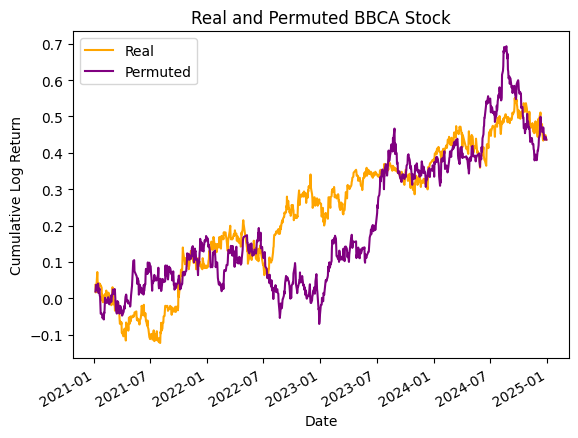

In [ ]:
df_perm = get_permutation(train_df)

real_r = np.log(train_df['Close']).diff()
perm_r = np.log(df_perm['Close']).diff()

print(f"Mean. REAL: {real_r.mean():14.6f} PERM: {perm_r.mean():14.6f}")
print(f"Stdd. REAL: {real_r.std():14.6f} PERM: {perm_r.std():14.6f}")
print(f"Skew. REAL: {real_r.skew():14.6f} PERM: {perm_r.skew():14.6f}")
print(f"Kurt. REAL: {real_r.kurt():14.6f} PERM: {perm_r.kurt():14.6f}")

np.log(train_df['Close']).diff().cumsum().plot(color='orange', label='Real')
np.log(df_perm['Close']).diff().cumsum().plot(color='purple', label='Permuted')

plt.ylabel("Cumulative Log Return")
plt.title("Real and Permuted BBCA Stock")
plt.legend()
plt.show()

Your permutation method preserves:

* What stays similar:
  * Return distribution (mean, variance, skew, kurtosis)
  * Volatility level
  * Candle shapes (intrabar high/low/close behavior)
  * Gap statistics (open vs previous close)
  * Price scale (log-space reconstruction)

* So when you plot cumulative log returns, both series:
  * Drift within a similar range
  * Exhibit similar drawdowns
  * Have comparable volatility clustering in appearance

* What is not preserved (and why it matters)
  * Autocorrelation
  * Trend persistence
  * Regime structure
  * Momentum / mean reversion
  * Any causal ordering


## Long when Price Rises Above SMA

In [ ]:
def get_signal(close: pd.Series, sma_period: int) -> pd.Series:
  # Calculate sma
  sma = close.rolling(sma_period).mean()

  # Calculate the signal
  signal = (close > sma).astype(int)
  return signal

In [ ]:
# Create hyperopt space
space = {
    'sma_period': hp.choice('sma_period', range(5, 50))
}

# Create objective function for optimize the strategy
def objective(data:pd.DataFrame, params:dict):
  # Get signal
  signal = get_signal(data['Close'], params['sma_period'])

  # Calculate signal return
  actual_return = np.log(data['Close']).diff().shift(-1)
  strategy_return = signal * actual_return

  profit_factor = strategy_return[strategy_return > 0].sum() / strategy_return[strategy_return < 0].abs().sum()
  sharpe_ratio = strategy_return.mean() / strategy_return.std()

  return sharpe_ratio

In [ ]:
# Optimize the strategy
best = fmin(
    fn=lambda params: -objective(train_df, params),
    space=space,
    algo=tpe.suggest,
    max_evals=1000
)

100%|██████████| 1000/1000 [00:09<00:00, 109.73trial/s, best loss: 0.0020790443768702034]


As you can see from the output, the Sharpe Ratio changes for different `sma_period` values. The optimal `sma_period` found by `hyperopt` was 34, which resulted in the highest Sharpe Ratio (least negative in this case) during the optimization process. The overall Sharpe Ratios are quite low (and negative) for this particular strategy and training period, which suggests that the simple SMA crossover might not be very effective on its own for BBCA stock during the 2021-2024 period.

## Trend Following Strategy: MA Crossover
* Two EMA crossover:
  * Long signal: the short-term EMA crosses above the long-term EMA
  * Short signal: the short-term EMA crosses below the long-term EMA


In [ ]:
def get_ma_crossover_signal(close: pd.Series, short_period: int, long_period: int) -> pd.Series:
  # Calculate short period EMA and long period EMA
  short_period_ema = close.ewm(span=short_period, adjust=False).mean()
  long_period_ema = close.ewm(span=long_period, adjust=False).mean()

  # Calculate the signal
  signal = (short_period_ema > long_period_ema).astype(int)
  return signal

In [ ]:
params = {
    'long_period': scope.int(hp.quniform('long_period', 10, 50, 1)),
    'delta': scope.int(hp.quniform('delta', 1, 20, 1))
}

def objective(data:pd.DataFrame, params):
    long_p = params['long_period']
    short_p = long_p - params['delta']

    # Enforce constraint
    if short_p < 1 or short_p >= long_p:
        return {"loss": 1e6, "status": STATUS_OK}

    signal = get_ma_crossover_signal(data['Close'], short_p, long_p)

    actual_return = np.log(data['Close']).diff().shift(-1)
    strategy_return = signal * actual_return
    strategy_return = strategy_return.dropna()

    std = strategy_return.std()
    if std == 0 or np.isnan(std):
        return {"loss": 1e6, "status": STATUS_OK}

    sharpe = strategy_return.mean() / std

    # Hyperopt minimizes
    loss = -sharpe

    return {
        "loss": loss,
        "status": STATUS_OK,
        "short_period": short_p,
        "long_period": long_p,
        "sharpe": sharpe
    }


In [ ]:
# Optimize the strategy
best = fmin(
    fn=lambda params: objective(train_df, params),
    space=params, # Use the correct space variable as defined in the cell above
    algo=tpe.suggest,
    max_evals=1000
)

100%|██████████| 1000/1000 [00:50<00:00, 19.97trial/s, best loss: -0.03125700731720802]


# Others

In [ ]:
def prepare_features(df, horizon=1, add_lags=True, n_lags=3, feature_set='full'):
    """
    Enhanced feature engineering for trading models.

    Parameters:
    -----------
    df : pd.DataFrame
        OHLCV data with columns: Open, High, Low, Close, Volume
    horizon : int
        Number of periods ahead for target calculation
    add_lags : bool
        Whether to add lagged features
    n_lags : int
        Number of lag periods to create
    feature_set : str
        'basic' (original features only), 'enhanced' (adds best features),
        'full' (all features)

    Returns:
    --------
    pd.DataFrame with features and target variable
    """
    df = df.copy()

    # ==================== ORIGINAL FEATURES ====================
    # EMAs
    df["EMA20"] = talib.EMA(df["Close"], 20)
    df["EMA50"] = talib.EMA(df["Close"], 50)
    df["EMA_spread"] = df["EMA20"] - df["EMA50"]

    # MACD
    df["MACD"], df["MACD_signal"], df["MACD_hist"] = talib.MACD(df["Close"])

    # RSI
    df["RSI14"] = talib.RSI(df["Close"], 14)

    # Bollinger
    df["BB_upper"], df["BB_middle"], df["BB_lower"] = talib.BBANDS(df["Close"])
    df["BB_pctB"] = (df["Close"] - df["BB_lower"]) / (df["BB_upper"] - df["BB_lower"])
    df["BB_width"] = (df["BB_upper"] - df["BB_lower"]) / df["EMA20"]

    # OBV
    df["OBV"] = talib.OBV(df["Close"], df["Volume"])
    df["OBV_diff"] = df["OBV"].diff()

    # Returns & Vol
    df["ret1"] = df["Close"].pct_change(1)
    df["ret5"] = df["Close"].pct_change(5)
    df["rolling_vol20"] = df["ret1"].rolling(20).std()

    # Market Regimes
    df["SMA200"] = talib.SMA(df["Close"], 200)
    df["trend_regime"] = (df["Close"] > df["SMA200"]).astype(int)
    df["vol_regime"] = (df["rolling_vol20"] > df["rolling_vol20"].median()).astype(int)

    # Candle structure
    df["body"] = df["Close"] - df["Open"]
    df["range"] = df["High"] - df["Low"]
    df["upper_wick"] = df["High"] - df[["Open", "Close"]].max(axis=1)
    df["lower_wick"] = df[["Open", "Close"]].min(axis=1) - df["Low"]

    if feature_set in ['enhanced', 'full']:
        # ==================== ENHANCED FEATURES ====================

        # 1. VOLATILITY FEATURES
        df["ATR14"] = talib.ATR(df["High"], df["Low"], df["Close"], 14)
        df["ATR_pct"] = df["ATR14"] / df["Close"]
        df["vol_ratio_5_20"] = df["ret1"].rolling(5).std() / (df["rolling_vol20"] + 1e-10)
        df["HL_spread_pct"] = (df["High"] - df["Low"]) / df["Close"]

        # 2. VOLUME FEATURES
        df["Volume_MA20"] = df["Volume"].rolling(20).mean()
        df["volume_ratio"] = df["Volume"] / (df["Volume_MA20"] + 1)
        df["MFI"] = talib.MFI(df["High"], df["Low"], df["Close"], df["Volume"], 14)
        df["volume_momentum"] = df["volume_ratio"] * df["ret1"]

        # 3. PRICE ACTION & MOMENTUM
        df["ROC10"] = talib.ROC(df["Close"], 10)
        df["dist_from_EMA20"] = (df["Close"] - df["EMA20"]) / df["EMA20"]
        df["dist_from_SMA200"] = (df["Close"] - df["SMA200"]) / df["SMA200"]
        df["ret1_change"] = df["ret1"].diff()  # Price acceleration
        df["ret10"] = df["Close"].pct_change(10)
        df["ret20"] = df["Close"].pct_change(20)

        # 4. CANDLE PATTERNS ENHANCED
        df["body_range_ratio"] = df["body"].abs() / (df["range"] + 1e-10)
        df["upper_wick_ratio"] = df["upper_wick"] / (df["range"] + 1e-10)
        df["lower_wick_ratio"] = df["lower_wick"] / (df["range"] + 1e-10)
        df["bullish_candle"] = (df["body"] > 0).astype(int)

        # 5. SUPPORT/RESISTANCE
        df["rolling_max20"] = df["High"].rolling(20).max()
        df["rolling_min20"] = df["Low"].rolling(20).min()
        df["dist_from_high"] = (df["rolling_max20"] - df["Close"]) / df["rolling_max20"]
        df["dist_from_low"] = (df["Close"] - df["rolling_min20"]) / (df["Close"] + 1e-10)

        # 6. INTERACTION FEATURES
        df["RSI_vol_interaction"] = df["RSI14"] * df["rolling_vol20"]
        df["MACD_normalized"] = df["MACD_hist"] / (df["ATR14"] + 1e-10)
        df["trend_strength"] = df["EMA_spread"] / (df["ATR14"] + 1e-10)

        # 7. STATISTICAL FEATURES
        df["price_zscore"] = (df["Close"] - df["Close"].rolling(50).mean()) / (df["Close"].rolling(50).std() + 1e-10)
        df["volume_zscore"] = (df["Volume"] - df["Volume_MA20"]) / (df["Volume"].rolling(20).std() + 1e-10)

        # 8. REGIME FEATURES
        df["consecutive_up"] = (df["ret1"] > 0).rolling(5).sum()
        df["market_phase"] = df["trend_regime"] * 2 + df["vol_regime"]

        # 9. ROLLING STATISTICS
        df["RSI14_ma3"] = df["RSI14"].rolling(3).mean()
        df["MACD_hist_std3"] = df["MACD_hist"].rolling(3).std()

    if feature_set == 'full':
        # ==================== ADDITIONAL FULL FEATURES ====================

        # More technical indicators
        df["CCI14"] = talib.CCI(df["High"], df["Low"], df["Close"], 14)
        df["ADX14"] = talib.ADX(df["High"], df["Low"], df["Close"], 14)
        df["WILLR14"] = talib.WILLR(df["High"], df["Low"], df["Close"], 14)

        # Stochastic
        df["STOCH_K"], df["STOCH_D"] = talib.STOCH(df["High"], df["Low"], df["Close"])

        # Volume indicators
        df["AD"] = talib.AD(df["High"], df["Low"], df["Close"], df["Volume"])
        df["ADOSC"] = talib.ADOSC(df["High"], df["Low"], df["Close"], df["Volume"])

        # More statistical features
        df["ret_skew20"] = df["ret1"].rolling(20).skew()
        df["ret_kurt20"] = df["ret1"].rolling(20).apply(lambda x: pd.Series(x).kurtosis())

        # Gap features
        df["gap"] = df["Open"] - df["Close"].shift(1)
        df["gap_pct"] = df["gap"] / (df["Close"].shift(1) + 1e-10)

        # More regime features
        df["vol_percentile"] = df["rolling_vol20"].rolling(100).apply(
            lambda x: pd.Series(x).rank(pct=True).iloc[-1] if len(x) > 0 else np.nan
        )

    # ==================== LAGS ====================
    if add_lags:
        # Base lag features
        base_lag_cols = ["EMA_spread", "MACD_hist", "RSI14", "BB_pctB", "OBV_diff", "ret1"]

        # Enhanced lag features
        if feature_set in ['enhanced', 'full']:
            base_lag_cols.extend([
                "volume_ratio", "ATR_pct", "body_range_ratio",
                "ret5", "MFI", "MACD_normalized"
            ])

        for col in base_lag_cols:
            if col in df.columns:
                for lag in range(1, n_lags + 1):
                    df[f"{col}_lag{lag}"] = df[col].shift(lag)

    # ==================== TARGET ====================
    df["future_ret"] = df["Close"].shift(-horizon) / df["Close"] - 1
    df["is_long"] = (df["future_ret"] > 0).astype(int)

    # Drop future return since it is causing leakage
    df = df.drop(["future_ret", "Close"], axis=1)

    return df.dropna()

In [ ]:
# 1️⃣ Compute indicators on the entire dataset (train + test)
df = prepare_features(data, n_lags=20)

##